In [1]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import warnings 
import re
from bs4 import BeautifulSoup
warnings.filterwarnings("ignore")

## “How does qualification level influence salary distribution in government job listings?”

## 1️⃣Raw Data Structure

### Initially dataset contained:

##### Observed that salary column contained mixed formats (single value, range, “No Details”), and title column combined organization and role information.

|Column |	Description|
|:--|:--|
|title	|Full job listing title|
|link|	Job detail URL|
|job_type	|Government / etc
|qualification	|Raw qualification text
|salary	|Raw salary string

In [96]:
df = pd.read_csv("raw_job_data.csv")
df.head()

,title,link,Job Type,Qualification,Salary
0,South Indian Bank Recruitment 2026 - Junior Of...,https://www.jobkaka.com/sib-junior-officer-post/,Government,Graduate,Rs.756000/-
1,CSIR-National Aerospace Laboratories Recruitme...,https://www.jobkaka.com/csir-nal-project-assoc...,Government,Graduate,Rs.25000-25000/-
2,Fertilizer Corporation of India Limited (FCIL)...,https://www.jobkaka.com/fcil-young-professiona...,Government,Graduate,Rs.30000-60000/-
3,Arunachal Pradesh Public Service Commission Re...,https://www.jobkaka.com/appsc-assistant-profes...,Government,Master's,Rs.57700-182400/-
4,Hindustan Petroleum Corporation Limited (HPCL)...,https://www.jobkaka.com/hpcl-graduate-apprenti...,Government,Graduate,Rs.25000-25000/-


## 2️⃣ Data Cleaning & Feature Engineering

The raw dataset required structured cleaning and transformation to enable meaningful analytical insights. Below are the transformations performed:

---

### 🔹 1. Salary Cleaning & Normalization

The original `salary` column contained:

- Single salary values (e.g., Rs. 40,000/-)
- Salary ranges (e.g., Rs. 30,000–60,000/-)
- Missing values ("No Details")
- Mixed annual and monthly salary formats

#### Transformations Performed:

- Extracted numeric values using Regular Expressions (Regex).
- Created:
  - `salary_minimum`
  - `salary_maximum`
- For single values → assigned same value to both min and max.
- Converted missing values to `NULL`.
- Identified annual salaries using a heuristic rule (`salary > 200000`) and converted them to monthly values.
- Created additional features:
  - `salary_range` = salary_maximum − salary_minimum
  - `salary_band` (Low / Medium / High)

> Salary normalization was required because the raw dataset contained mixed annual and monthly salary formats, which distorted the overall statistical distribution.

---

In [97]:
# we start with Salary column
# -------------------------------------
df["Salary"].sample(20)

689            No Details
63      Rs.56100-208700/-
49       Rs.28740-72110/-
307     Rs.97220-209445/-
577    Rs.160000-160000/-
677            No Details
813            No Details
854            No Details
599            No Details
919             Rs.9000/-
302     Rs.44900-208700/-
164      Rs.12300-12300/-
372            Rs.10000/-
305      Rs.12000-12000/-
206      Rs.15600-39100/-
403     Rs.78800-209200/-
549            No Details
532      Rs.31000-31000/-
624            Rs.45000/-
82             No Details
Name: Salary, dtype: object

In [98]:
salary_string = list(df["Salary"])
sal_min = []
sal_max = []
for s in salary_string:
    num = re.findall(r"\d+", s)
    # print(s," : ", numbers)
    if len(num) == 2:
        sal_min.append(num[0])
        sal_max.append(num[1])
    elif len(num) == 1:
        sal_min.append(num[0])
        sal_max.append(num[0])
    elif len(num) == 0:
        sal_min.append(None)
        sal_max.append(None)

In [99]:
df["salary_minimum"] = sal_min
df["salary_maximum"] = sal_max

In [100]:
df.head()

,title,link,Job Type,Qualification,Salary,salary_minimum,salary_maximum
0,South Indian Bank Recruitment 2026 - Junior Of...,https://www.jobkaka.com/sib-junior-officer-post/,Government,Graduate,Rs.756000/-,756000,756000
1,CSIR-National Aerospace Laboratories Recruitme...,https://www.jobkaka.com/csir-nal-project-assoc...,Government,Graduate,Rs.25000-25000/-,25000,25000
2,Fertilizer Corporation of India Limited (FCIL)...,https://www.jobkaka.com/fcil-young-professiona...,Government,Graduate,Rs.30000-60000/-,30000,60000
3,Arunachal Pradesh Public Service Commission Re...,https://www.jobkaka.com/appsc-assistant-profes...,Government,Master's,Rs.57700-182400/-,57700,182400
4,Hindustan Petroleum Corporation Limited (HPCL)...,https://www.jobkaka.com/hpcl-graduate-apprenti...,Government,Graduate,Rs.25000-25000/-,25000,25000


In [101]:
# Checking for the data type of Integer columns.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1028 entries, 0 to 1027
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   title           1028 non-null   object
 1   link            1028 non-null   object
 2   Job Type        1028 non-null   object
 3   Qualification   1028 non-null   object
 4   Salary          1028 non-null   object
 5   salary_minimum  667 non-null    object
 6   salary_maximum  667 non-null    object
dtypes: object(7)
memory usage: 56.3+ KB


In [102]:
# The Numeric values from the object 
df["salary_minimum"] = pd.to_numeric(df["salary_minimum"], errors="coerce")
df["salary_maximum"] = pd.to_numeric(df["salary_maximum"], errors="coerce")

In [103]:
df.head()

,title,link,Job Type,Qualification,Salary,salary_minimum,salary_maximum
0,South Indian Bank Recruitment 2026 - Junior Of...,https://www.jobkaka.com/sib-junior-officer-post/,Government,Graduate,Rs.756000/-,756000.0,756000.0
1,CSIR-National Aerospace Laboratories Recruitme...,https://www.jobkaka.com/csir-nal-project-assoc...,Government,Graduate,Rs.25000-25000/-,25000.0,25000.0
2,Fertilizer Corporation of India Limited (FCIL)...,https://www.jobkaka.com/fcil-young-professiona...,Government,Graduate,Rs.30000-60000/-,30000.0,60000.0
3,Arunachal Pradesh Public Service Commission Re...,https://www.jobkaka.com/appsc-assistant-profes...,Government,Master's,Rs.57700-182400/-,57700.0,182400.0
4,Hindustan Petroleum Corporation Limited (HPCL)...,https://www.jobkaka.com/hpcl-graduate-apprenti...,Government,Graduate,Rs.25000-25000/-,25000.0,25000.0


####  We got to know the values are Less than

In [83]:
df[df["salary_minimum"] < 1000][["title", "salary_minimum", "salary_maximum"]]

,title,salary_minimum,salary_maximum
29,"Motilal Nehru College (Evening), University of...",10.0,10.0
65,"Central Sanskrit University (CSU), New Delhi R...",10.0,10.0
118,"Maitreyi College (University of Delhi), New De...",10.0,10.0
133,"All India Institute of Medical Sciences, Jammu...",13.0,13.0
429,Tata Institute of Fundamental Research Recruit...,10.0,10.0
475,Meghalaya Public Service Commission Recruitmen...,12.0,12.0
536,Sikkim Public Service Commission Recruitment 2...,15.0,15.0
615,Bihar Police Recruitment 2025 - Sub Inspector ...,6.0,6.0
821,High Court of Manipur Recruitment - Assistant ...,273.0,273.0


In [86]:
# checking for the values above 200000 (because governament jobs do not goes above that margin.)
salary_string = list(df["Salary"])
for s in salary_string:
    numbers = re.findall(r"\d+", s)
    if len(numbers) == 1:
        if int(numbers[0]) > 200000:
            print(numbers)

['756000']
['3000000']
['2815000']
['1080000']
['1700000']
['2600000']
['1295000']
['7000000']
['8000000']
['208700']
['280000']
['208700']
['280000']
['215900']
['280000']
['280000']
['300000']
['2250000']
['3600000']
['208700']
['201213']
['1600000']
['240000']
['1600000']
['700000']
['240000']
['208700']
['220000']


In [198]:
# convert the salaries from the annully mixed to montly once.

df["salary_type"] = df["salary_minimum"].apply(lambda x: "annual" if x and x > 200000 else "monthly")

In [199]:
df.loc[df["salary_type"] == "annual", "salary_minimum"] /= 12
df.loc[df["salary_type"] == "annual", "salary_maximum"] /= 12

In [104]:
df.head()

,title,link,Job Type,Qualification,Salary,salary_minimum,salary_maximum
0,South Indian Bank Recruitment 2026 - Junior Of...,https://www.jobkaka.com/sib-junior-officer-post/,Government,Graduate,Rs.756000/-,756000.0,756000.0
1,CSIR-National Aerospace Laboratories Recruitme...,https://www.jobkaka.com/csir-nal-project-assoc...,Government,Graduate,Rs.25000-25000/-,25000.0,25000.0
2,Fertilizer Corporation of India Limited (FCIL)...,https://www.jobkaka.com/fcil-young-professiona...,Government,Graduate,Rs.30000-60000/-,30000.0,60000.0
3,Arunachal Pradesh Public Service Commission Re...,https://www.jobkaka.com/appsc-assistant-profes...,Government,Master's,Rs.57700-182400/-,57700.0,182400.0
4,Hindustan Petroleum Corporation Limited (HPCL)...,https://www.jobkaka.com/hpcl-graduate-apprenti...,Government,Graduate,Rs.25000-25000/-,25000.0,25000.0


In [213]:
# creating the feaure salary band

def salary_band(x):
    if pd.isna(x):
        return np.nan
    elif x < 30000:
        return "Low"
    elif x < 70000:
        return "Medium"
    elif x < 150000:
        return "High"
    else:
        return "Very High"

df["salary_band"] = df["salary_minimum"].apply(salary_band)

In [214]:
df[["salary_minimum","salary_maximum"]]

,salary_minimum,salary_maximum
0,"63,000","63,000"
1,"25,000","25,000"
2,"30,000","60,000"
3,"57,700","182,400"
4,"25,000","25,000"
...,...,...
1023,NaN,NaN
1024,NaN,NaN
1025,NaN,NaN
1026,NaN,NaN


In [215]:
df["salary_range"] = df["salary_maximum"] - df["salary_minimum"]

In [216]:
df.isnull().sum()

Job Type                 0
salary_minimum         361
salary_maximum         361
salary_band            361
salary_range           361
qualification_level      0
sector                   0
role_category            0
dtype: int64

In [92]:
df["salary_minimum"].isna().sum()

np.int64(361)

In [147]:
df.head()

,Job Type,salary_minimum,salary_maximum,salary_band,salary_range,qualification_level,sector,role_category
0,Government,756000.0,756000.0,null_val,0.0,undergraduate,Banking,Officer
1,Government,25000.0,25000.0,Low,0.0,undergraduate,Government General,Associate
2,Government,30000.0,60000.0,Medium,30000.0,undergraduate,PSU,Other
3,Government,57700.0,182400.0,Medium,124700.0,postgraduate,Government Admin,Academic
4,Government,25000.0,25000.0,Low,0.0,undergraduate,PSU,Engineer


#### we can observe the Qualification Column. 

### 🔹 2. Qualification Standardization

The `qualification` column contained multiple textual variations such as:

- Graduate
- Graduation
- Bachelor Degree
- Master's
- Postgraduate
- Diploma
- 10th / 12th

#### Transformations Performed:

- Converted text to lowercase.
- Applied keyword-based mapping to standardize education levels.
- Created a new column: `qualification_level`, categorized into:

  - `undergraduate`
  - `postgraduate`
  - `doctorate`
  - `diploma`
  - `school_level`
  - `other`

Priority rules were applied to prevent misclassification (e.g., “postgraduate” incorrectly matching “graduate”).

---

In [111]:
df["Qualification"].value_counts().head(50)

Qualification
Graduate                                                   455
Master's                                                   125
Postgraduate                                                20
Bachelor Degree                                             17
Graduation                                                  13
Degree                                                      12
Doctorate                                                   11
Not Applicable                                               9
Intermediate (12th)                                          8
Diploma                                                      7
Professional                                                 7
Bachelors degree                                             7
Bachelor's                                                   6
Post Graduate                                                6
Any Degree                                                   6
graduate                                 

In [113]:
df["qualification_clean"] = df["Qualification"].str.lower()

In [114]:
df["qualification_clean"].value_counts()

qualification_clean
graduate                                                                                        460
master's                                                                                        125
postgraduate                                                                                     20
bachelor degree                                                                                  17
degree                                                                                           13
                                                                                               ... 
be / btech in electronics/ instrumentation and min 1 year experience                              1
bsc nursing                                                                                       1
bachelors degree in engineering or post-graduation in geoscience and min 20 years experience      1
m.e. /m.tech.                                                                   

In [115]:
df["qualification_level"] = ["other"]*1028

In [116]:
# Doctorate
df.loc[df["qualification_clean"].str.contains("phd|doctorate|doctoral", na=False),
       "qualification_level"] = "doctorate"
# Undergraduate
df.loc[df["qualification_clean"].str.contains("bachelor|graduate|b.tech|btech|b.e|bsc|degree|engineering", na=False),
       "qualification_level"] = "undergraduate"
# Postgraduate
df.loc[df["qualification_clean"].str.contains("master|postgraduate|post graduate|mba|m.tech", na=False),
       "qualification_level"] = "postgraduate"
# Diploma
df.loc[df["qualification_clean"].str.contains("diploma|iti", na=False),
       "qualification_level"] = "diploma"
# School
df.loc[df["qualification_clean"].str.contains("10th|12th|intermediate|10\\+2", na=False),
       "qualification_level"] = "school_level"

In [117]:
df["qualification_level"].value_counts()

qualification_level
undergraduate    648
postgraduate     183
other             89
diploma           46
school_level      46
doctorate         16
Name: count, dtype: int64

In [118]:
# we do verify the column match with classification

df.loc[df["qualification_level"]=="other"][["qualification_clean","qualification_level"]]

,qualification_clean,qualification_level
69,professional,other
265,professional,other
298,professional,other
423,professional,other
434,not specified,other
...,...,...
1004,graduation,other
1008,gate/net,other
1015,(b. ed.),other
1017,0,other


In [119]:
df.head()

,title,link,Job Type,Qualification,Salary,salary_minimum,salary_maximum,salary_band,salary_range,qualification_clean,qualification_level
0,South Indian Bank Recruitment 2026 - Junior Of...,https://www.jobkaka.com/sib-junior-officer-post/,Government,Graduate,Rs.756000/-,756000.0,756000.0,High,0.0,graduate,undergraduate
1,CSIR-National Aerospace Laboratories Recruitme...,https://www.jobkaka.com/csir-nal-project-assoc...,Government,Graduate,Rs.25000-25000/-,25000.0,25000.0,Low,0.0,graduate,undergraduate
2,Fertilizer Corporation of India Limited (FCIL)...,https://www.jobkaka.com/fcil-young-professiona...,Government,Graduate,Rs.30000-60000/-,30000.0,60000.0,Medium,30000.0,graduate,undergraduate
3,Arunachal Pradesh Public Service Commission Re...,https://www.jobkaka.com/appsc-assistant-profes...,Government,Master's,Rs.57700-182400/-,57700.0,182400.0,Medium,124700.0,master's,postgraduate
4,Hindustan Petroleum Corporation Limited (HPCL)...,https://www.jobkaka.com/hpcl-graduate-apprenti...,Government,Graduate,Rs.25000-25000/-,25000.0,25000.0,Low,0.0,graduate,undergraduate


### 🔹 3. Title-Based Feature Engineering

The `title` column originally combined organization and job role information.

Example format:

#### Transformations Performed:

- Split title into:
  - `organization_part`
  - `role_part`
- Extracted:
  - `sector` (e.g., Banking, Education, Healthcare, PSU, Government Admin)
  - `role_category` (e.g., Officer, Engineer, Assistant, Managerial, Research, Academic)

Keyword-based mapping with priority hierarchy was used to ensure accurate classification.

---

##### Job Title contain the values like [ Organization_name - year - Job_Title ]

In [120]:
df["has_dash"] = df["title"].str.contains(" - ")
df["has_dash"].value_counts()

has_dash
True    1028
Name: count, dtype: int64

In [249]:
df[["organization_part", "role_part"]] = df_old["title"].str.split(" - ", n=1, expand=True)

In [124]:
from collections import Counter

org_words = []
role_words = []

for title in df["organization_part"]:
    words = re.findall(r"[A-Za-z]+", title.lower())
    org_words.extend(words)

for title in df["role_part"]:
    words = re.findall(r"[A-Za-z]+", title.lower())
    role_words.extend(words)

In [125]:
org_counts = Counter(org_words)
role_counts = Counter(role_words)

In [126]:
org_counts.most_common(30)

[('recruitment', 1038),
 ('of', 308),
 ('limited', 225),
 ('institute', 193),
 ('india', 133),
 ('national', 124),
 ('and', 108),
 ('bank', 100),
 ('commission', 97),
 ('service', 92),
 ('corporation', 82),
 ('public', 81),
 ('indian', 79),
 ('technology', 71),
 ('research', 63),
 ('university', 58),
 ('pradesh', 53),
 ('central', 48),
 ('development', 45),
 ('board', 38),
 ('state', 37),
 ('court', 36),
 ('medical', 36),
 ('high', 35),
 ('selection', 33),
 ('for', 33),
 ('sciences', 31),
 ('power', 31),
 ('company', 30),
 ('delhi', 26)]

In [127]:
role_counts.most_common(30)

[('jobs', 1028),
 ('and', 190),
 ('assistant', 175),
 ('other', 147),
 ('officer', 129),
 ('various', 123),
 ('manager', 113),
 ('junior', 91),
 ('engineer', 74),
 ('project', 68),
 ('research', 61),
 ('associate', 53),
 ('senior', 51),
 ('graduate', 50),
 ('i', 44),
 ('apprentice', 44),
 ('trainee', 44),
 ('grade', 40),
 ('fellow', 40),
 ('medical', 38),
 ('posts', 37),
 ('general', 33),
 ('executive', 32),
 ('technical', 31),
 ('civil', 30),
 ('iii', 25),
 ('deputy', 25),
 ('engineering', 24),
 ('teacher', 24),
 ('ii', 23)]

In [128]:
def extract_sector(org):
    org = org.lower()
    
    if "bank" in org:
        return "Banking"
    elif "university" in org or "institute" in org:
        return "Education"
    elif "medical" in org or "hospital" in org:
        return "Healthcare"
    elif "court" in org:
        return "Judiciary"
    elif "power" in org:
        return "Energy"
    elif "corporation" in org:
        return "PSU"
    elif "commission" in org or "board" in org:
        return "Government Admin"
    elif "technology" in org or "research" in org:
        return "Technical/Research"
    else:
        return "Government General"

In [129]:
df["sector"] = df["organization_part"].apply(extract_sector)

In [130]:
def extract_role(role):
    role = role.lower()
    
    if "professor" in role or "teacher" in role:
        return "Academic"
    elif "research" in role or "fellow" in role:
        return "Research"
    elif "engineer" in role or "engineering" in role:
        return "Engineer"
    elif "manager" in role or "executive" in role or "deputy" in role:
        return "Managerial"
    elif "officer" in role:
        return "Officer"
    elif "assistant" in role:
        return "Assistant"
    elif "apprentice" in role or "trainee" in role:
        return "Entry Level"
    elif "associate" in role:
        return "Associate"
    elif "medical" in role:
        return "Medical"
    else:
        return "Other"

In [131]:
df["role_category"] = df["role_part"].apply(extract_role)

In [132]:
df["role_category"].value_counts()

role_category
Other          354
Managerial     142
Officer        117
Assistant       93
Engineer        91
Entry Level     79
Research        65
Academic        43
Associate       36
Medical          8
Name: count, dtype: int64

In [133]:
df["sector"].value_counts()

sector
Government General    375
Education             243
Government Admin      133
Banking               106
PSU                    65
Judiciary              35
Energy                 31
Technical/Research     24
Healthcare             16
Name: count, dtype: int64

In [134]:
df.head()

,title,link,Job Type,Qualification,Salary,salary_minimum,salary_maximum,salary_band,salary_range,qualification_clean,qualification_level,has_dash,organization_part,role_part,sector,role_category
0,South Indian Bank Recruitment 2026 - Junior Of...,https://www.jobkaka.com/sib-junior-officer-post/,Government,Graduate,Rs.756000/-,756000.0,756000.0,High,0.0,graduate,undergraduate,True,South Indian Bank Recruitment 2026,Junior Officer Jobs,Banking,Officer
1,CSIR-National Aerospace Laboratories Recruitme...,https://www.jobkaka.com/csir-nal-project-assoc...,Government,Graduate,Rs.25000-25000/-,25000.0,25000.0,Low,0.0,graduate,undergraduate,True,CSIR-National Aerospace Laboratories Recruitme...,Project Associate-I Jobs,Government General,Associate
2,Fertilizer Corporation of India Limited (FCIL)...,https://www.jobkaka.com/fcil-young-professiona...,Government,Graduate,Rs.30000-60000/-,30000.0,60000.0,Medium,30000.0,graduate,undergraduate,True,Fertilizer Corporation of India Limited (FCIL)...,"Young Professional (Finance, Company Secretary...",PSU,Other
3,Arunachal Pradesh Public Service Commission Re...,https://www.jobkaka.com/appsc-assistant-profes...,Government,Master's,Rs.57700-182400/-,57700.0,182400.0,Medium,124700.0,master's,postgraduate,True,Arunachal Pradesh Public Service Commission Re...,Assistant Professor (Various Disciplines) Jobs,Government Admin,Academic
4,Hindustan Petroleum Corporation Limited (HPCL)...,https://www.jobkaka.com/hpcl-graduate-apprenti...,Government,Graduate,Rs.25000-25000/-,25000.0,25000.0,Low,0.0,graduate,undergraduate,True,Hindustan Petroleum Corporation Limited (HPCL)...,Graduate Apprentice (Engineering) - Civil / Me...,PSU,Engineer


### 3️⃣ Data Cleaning

1️⃣ Demand analysis
1️⃣ Fix structural errors (unit mismatch)
2️⃣ Fix extreme misparsed values
3️⃣ Then handle missing values
4️⃣ Then handle statistical outliers

In [13]:
df = pd.read_csv("Job_data_cleaned_1.csv")
df.head()

,Job Type,salary_minimum,salary_maximum,salary_band,salary_range,qualification_level,sector,role_category
0,Government,"63,000","63,000",Medium,0,undergraduate,Banking,Officer
1,Government,"25,000","25,000",Low,0,undergraduate,Government General,Associate
2,Government,"30,000","60,000",Medium,"30,000",undergraduate,PSU,Other
3,Government,"57,700","182,400",Medium,"124,700",postgraduate,Government Admin,Academic
4,Government,"25,000","25,000",Low,0,undergraduate,PSU,Engineer


In [16]:
df.shape

(1019, 8)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1019 entries, 0 to 1018
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Job Type             1019 non-null   object 
 1   salary_minimum       658 non-null    float64
 2   salary_maximum       658 non-null    float64
 3   salary_band          658 non-null    object 
 4   salary_range         658 non-null    float64
 5   qualification_level  1019 non-null   object 
 6   sector               1019 non-null   object 
 7   role_category        1019 non-null   object 
dtypes: float64(3), object(5)
memory usage: 63.8+ KB


In [10]:
# Making 
df["salary_minimum"] = df["salary_minimum"].round(0)
df["salary_maximum"] = df["salary_maximum"].round(0)

In [11]:
pd.options.display.float_format = '{:,.0f}'.format

In [12]:
df.describe()

,salary_minimum,salary_maximum,salary_range
count,658,658,658
mean,"52,878","81,767","28,889"
std,"50,886","73,626","51,966"
min,"1,000","1,000",0
25%,"25,000","30,640",0
50%,"40,000","56,100",0
75%,"65,000","120,940","32,250"
max,"666,667","666,667","415,000"


In [203]:
df.columns

Index(['Job Type', 'salary_minimum', 'salary_maximum', 'salary_band',
       'salary_range', 'qualification_level', 'sector', 'role_category'],
      dtype='object')

#### The following columns have no use for the analysis and only used for feature extraction.

In [136]:
df.drop(columns=['title', 'link', 'Qualification', 'Salary',
                 'qualification_clean','has_dash', 'organization_part', 'role_part'], inplace=True)

In [15]:
df.isna().sum()

Job Type                 0
salary_minimum         361
salary_maximum         361
salary_band            361
salary_range           361
qualification_level      0
sector                   0
role_category            0
dtype: int64

In [155]:
outliers = df.loc[[29,65,118,133,429,475,536,615,821],:]
outliers

,Job Type,salary_minimum,salary_maximum,salary_band,salary_range,qualification_level,sector,role_category
29,Government,10,10,Low,0,undergraduate,Education,Officer
65,Government,10,10,Low,0,undergraduate,Education,Other
118,Government,10,10,Low,0,postgraduate,Education,Academic
133,Government,13,13,Low,0,undergraduate,Education,Engineer
429,Government,10,10,Low,0,undergraduate,Education,Officer
475,Government,12,12,Low,0,undergraduate,Government Admin,Officer
536,Government,15,15,Low,0,undergraduate,Government Admin,Other
615,Government,6,6,Low,0,postgraduate,Government General,Other
821,Government,273,273,Low,0,undergraduate,Judiciary,Assistant


In [156]:
df = df.drop(index=[29,65,118,133,429,475,536,615,821])

In [204]:
df.shape

(1019, 8)

### 🔹 Final Analytical Dataset

After cleaning and feature engineering, the dataset included:

- `qualification_level`
- `salary_minimum`
- `salary_maximum`
- `salary_range`
- `salary_band`
- `sector`
- `role_category`

These engineered features enabled multi-dimensional analysis across education, role type, sector, and compensation levels.

### Save Cleaned Dataset
#### As it is getting more Cleaning steps involved like droping missing values and Outliers from the data, we save it. 

In [217]:
df.to_csv("Job_data_cleaned_1.csv",index=False)

In [2]:
df = pd.read_csv("Job_data_cleaned_1.csv")

#### pure data which have no null values.

## Handling Missing values and Outliers in Numerical columns.

### Missing Values Handling

In [28]:
import missingno as msno

In [ ]:
msno.matrix(df)

#### Approximately 35% of job listings did not disclose salary information. 
- These rows were retained for demand distribution analysis
- but excluded from salary-specific analysis.

In [53]:
per = (361/1019)*100
print(f"Total {per} of values are missing from the salary section.")

Total 35.426889106967614 of values are missing from the salary section.



#### 1. Droping the missing values

In [31]:
df_salary = df[df["salary_minimum"].notna()].copy()
df_salary # salary 

,Job Type,salary_minimum,salary_maximum,salary_band,salary_range,qualification_level,sector,role_category
0,Government,"63,000","63,000",Medium,0,undergraduate,Banking,Officer
1,Government,"25,000","25,000",Low,0,undergraduate,Government General,Associate
2,Government,"30,000","60,000",Medium,"30,000",undergraduate,PSU,Other
3,Government,"57,700","182,400",Medium,"124,700",postgraduate,Government Admin,Academic
4,Government,"25,000","25,000",Low,0,undergraduate,PSU,Engineer
...,...,...,...,...,...,...,...,...
996,Government,"44,900","142,400",Medium,"97,500",undergraduate,Healthcare,Officer
999,Government,"31,000","31,000",Medium,0,other,Education,Research
1000,Government,"37,000","37,000",Medium,0,undergraduate,Education,Engineer
1005,Government,"78,800","209,200",High,"130,400",undergraduate,Government General,Managerial


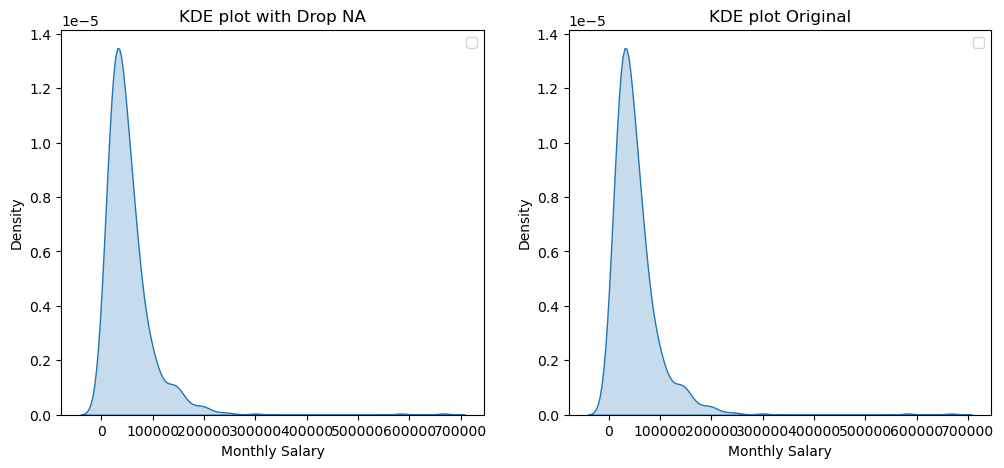

In [72]:
fig,axes = plt.subplots(1,2,figsize = (12,5))

sns.kdeplot(data=df_salary["salary_minimum"],ax=axes[0],fill=True) 
sns.kdeplot(data=df["salary_minimum"],ax=axes[1],fill=True)

axes[0].set_title("KDE plot with Drop NA")
axes[1].set_title("KDE plot Original")

axes[0].set_xlabel("Monthly Salary")
axes[0].set_ylabel("Density")

axes[1].set_xlabel("Monthly Salary")
axes[1].set_ylabel("Density")


axes[0].legend()
axes[1].legend()
plt.show()

#### 2. Handling data with missing values in Data distribution Analysis.

### Outliers Handling
---

In [81]:
# Minimum Salary Outliers
Q1 = df_salary["salary_minimum"].quantile(0.25)
Q3 = df_salary["salary_minimum"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [82]:
outliers = df_salary[(df_salary["salary_minimum"] < lower) | (df_salary["salary_minimum"] > upper)]

In [83]:
outliers.head()

,Job Type,salary_minimum,salary_maximum,salary_band,salary_range,qualification_level,sector,role_category
17,Government,"200,000","300,000",Very High,"100,000",undergraduate,Government General,Managerial
47,Government,"156,500","173,860",Very High,"17,360",postgraduate,Banking,Managerial
50,Government,"177,500","177,500",Very High,0,postgraduate,Education,Officer
72,Government,"142,400","142,400",High,0,undergraduate,Education,Officer
107,Government,"156,500","210,800",Very High,"54,300",undergraduate,Energy,Managerial


In [84]:
# Maximum Salary outliers

Q1 = df_salary["salary_maximum"].quantile(0.25)
Q3 = df_salary["salary_maximum"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_1 = df_salary[(df_salary["salary_maximum"] < lower) | (df_salary["salary_maximum"] > upper)]

In [85]:
outliers_1

,Job Type,salary_minimum,salary_maximum,salary_band,salary_range,qualification_level,sector,role_category
17,Government,"200,000","300,000",Very High,"100,000",undergraduate,Government General,Managerial
93,Government,"70,000","260,000",High,"190,000",undergraduate,Government General,Managerial
144,Government,"100,000","260,000",High,"160,000",undergraduate,Government General,Other
306,Government,"85,000","500,000",High,"415,000",postgraduate,Banking,Officer
430,Government,"100,000","260,000",High,"160,000",postgraduate,Government General,Managerial
494,Government,"583,333","583,333",Very High,0,undergraduate,Banking,Officer
505,Government,"666,667","666,667",Very High,0,undergraduate,Government General,Officer
699,Government,"100,000","260,000",High,"160,000",undergraduate,Government General,Other
749,Government,"300,000","300,000",Very High,0,undergraduate,PSU,Managerial
993,Government,"120,000","280,000",High,"160,000",undergraduate,Government General,Managerial


<Axes: xlabel='salary_minimum', ylabel='Density'>

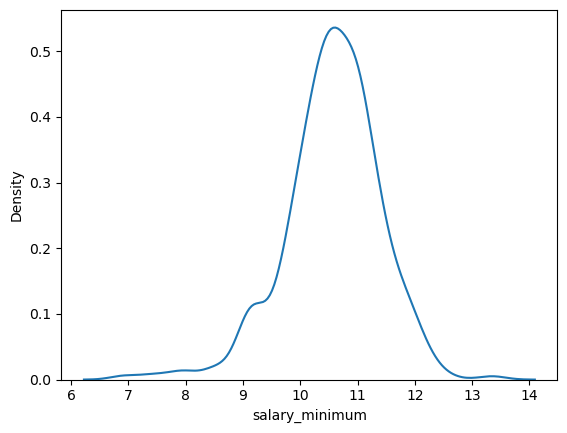

In [63]:
sns.kdeplot(np.log1p(df_salary["salary_minimum"]))

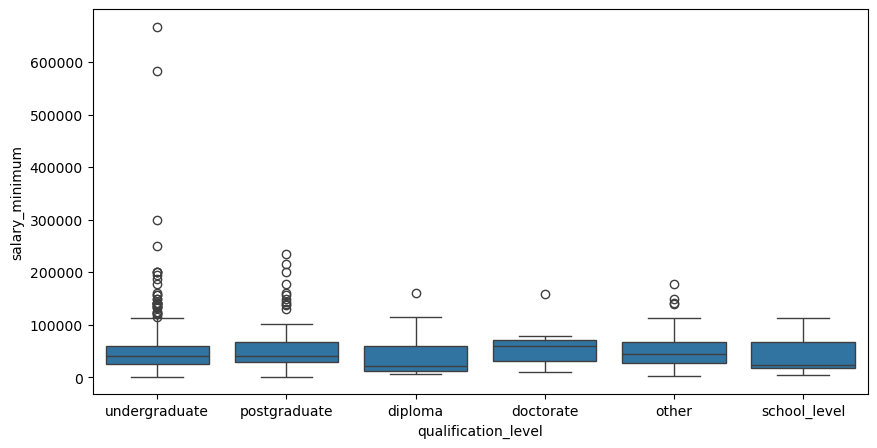

In [67]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df_salary, x="qualification_level", y="salary_minimum")
plt.show()

### Two typed Data

In [106]:
upper_limit = df_salary["salary_minimum"].quantile(0.99)
df_trimmed = df_salary[df_salary["salary_minimum"] <= upper_limit].copy()

In [105]:
df_trimmed

,Job Type,salary_minimum,salary_maximum,salary_band,salary_range,qualification_level,sector,role_category
0,Government,"63,000","63,000",Medium,0,undergraduate,Banking,Officer
1,Government,"25,000","25,000",Low,0,undergraduate,Government General,Associate
2,Government,"30,000","60,000",Medium,"30,000",undergraduate,PSU,Other
3,Government,"57,700","182,400",Medium,"124,700",postgraduate,Government Admin,Academic
4,Government,"25,000","25,000",Low,0,undergraduate,PSU,Engineer
...,...,...,...,...,...,...,...,...
996,Government,"44,900","142,400",Medium,"97,500",undergraduate,Healthcare,Officer
999,Government,"31,000","31,000",Medium,0,other,Education,Research
1000,Government,"37,000","37,000",Medium,0,undergraduate,Education,Engineer
1005,Government,"78,800","209,200",High,"130,400",undergraduate,Government General,Managerial


In [99]:
# to save updated data
df.to_csv("Job_Data_cleaned_1.csv",index=False)

In [100]:
df_trimmed.to_csv("Job_Data_Trimmed.csv",index=False)

## 🎯 Final Problem Statement (Strong Version)

#### How do sector and role categories interact with educational qualification to influence salary levels in government job listings?

## Insightful Questions
---
- Does higher qualification lead to higher salary?
- Which sectors pay more?
- Which roles dominate demand?
- Which sector hires mostly undergraduates?
- Are managerial roles always higher paying?
- Which roles have highest salary variability?

# 1. Full Data Analysis

## Category based Distribution Analysis
#### Total data Analysis with ouliers and Missing values.

In [101]:
df["qualification_level"].value_counts()

qualification_level
undergraduate    641
postgraduate     181
other             89
diploma           46
school_level      46
doctorate         16
Name: count, dtype: int64

##### Government hiring largely targets graduate-level roles rather than highly specialized academic roles.

In [103]:
# Doctorate and postgraduate roles are concentrated in Education sector.
df["sector"].value_counts()

sector
Government General    374
Education             238
Government Admin      131
Banking               106
PSU                    65
Judiciary              34
Energy                 31
Technical/Research     24
Healthcare             16
Name: count, dtype: int64

In [104]:
df["role_category"].value_counts()

role_category
Other          351
Managerial     142
Officer        114
Assistant       92
Engineer        90
Entry Level     79
Research        65
Academic        42
Associate       36
Medical          8
Name: count, dtype: int64

In [120]:
df["salary_band"].value_counts()

salary_band
Medium       309
Low          204
High         119
Very High     26
Name: count, dtype: int64

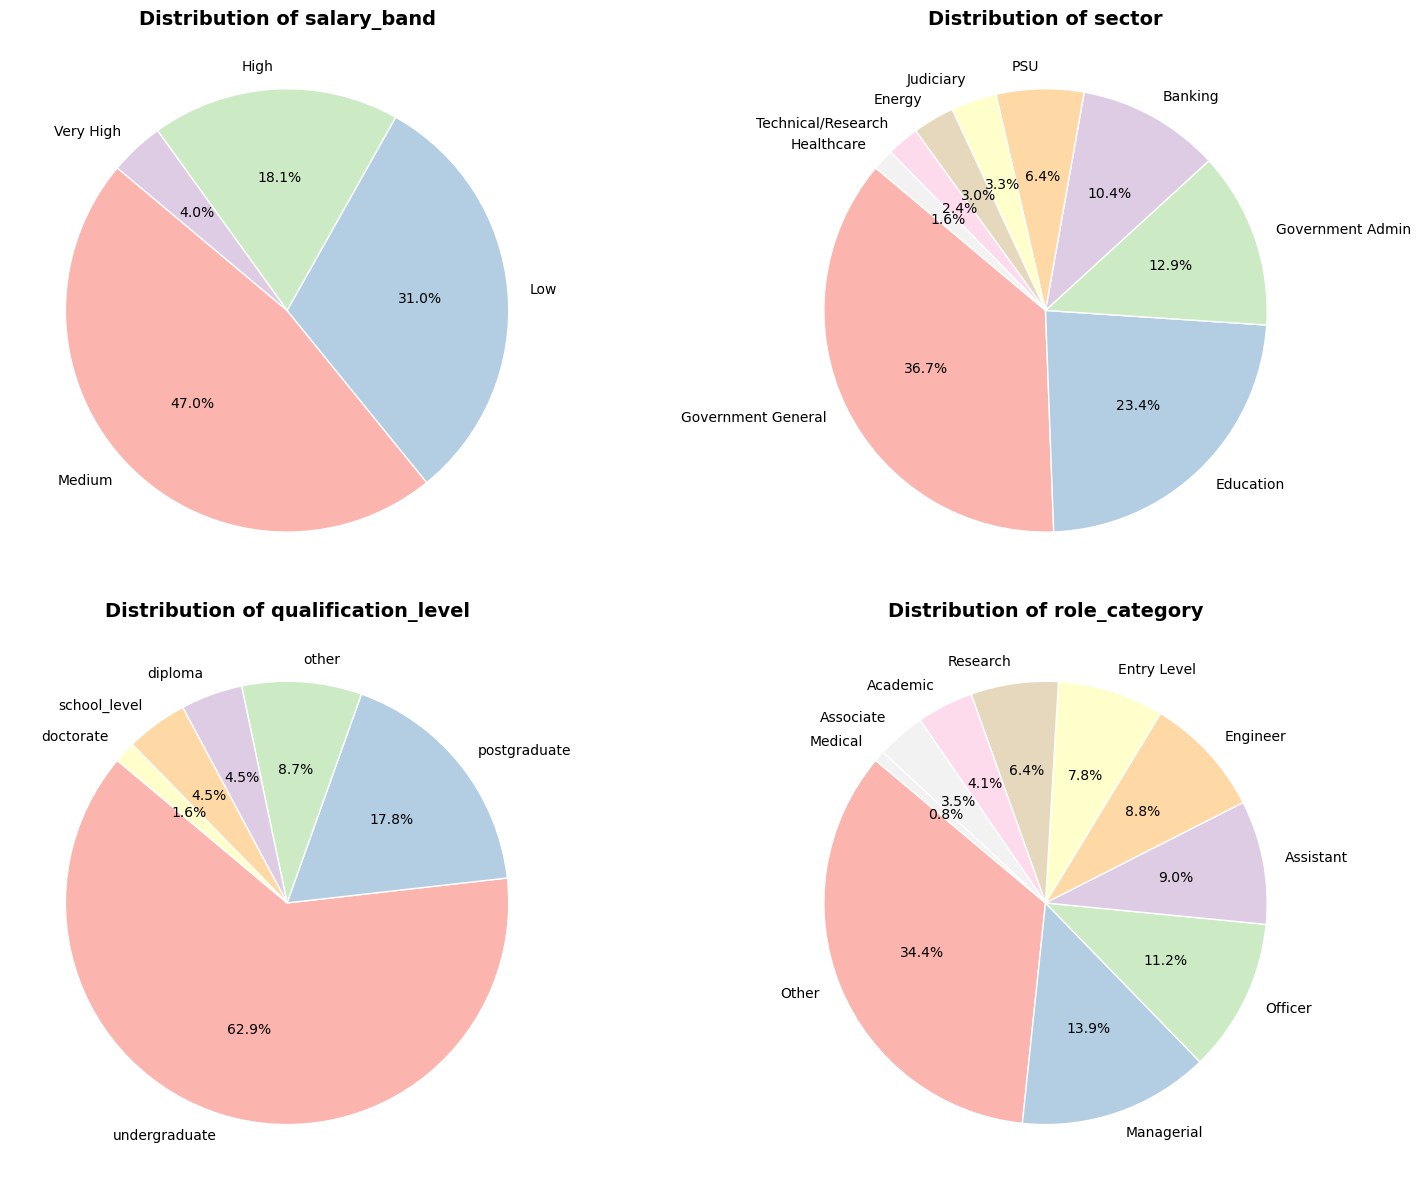

In [119]:
# Visual reresentation of the data

cat_cols = ['salary_band', 'qualification_level', 'sector', 'role_category']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
in_1 = [0,1,0,1]
in_2 = [0,0,1,1]

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    # Gpt Code
    axes[in_1[i],in_2[i]].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140, 
                colors=plt.cm.Pastel1(range(len(counts))),wedgeprops={'edgecolor': 'white'})
    
    axes[in_1[i],in_2[i]].set_title(f'Distribution of {col}', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Trimmed Data Analysis

### Salary Data Analysis

In [123]:
df_trimmed["salary_minimum"]

0       63,000
1       25,000
2       30,000
3       57,700
4       25,000
         ...  
996     44,900
999     31,000
1000    37,000
1005    78,800
1018   150,000
Name: salary_minimum, Length: 652, dtype: float64

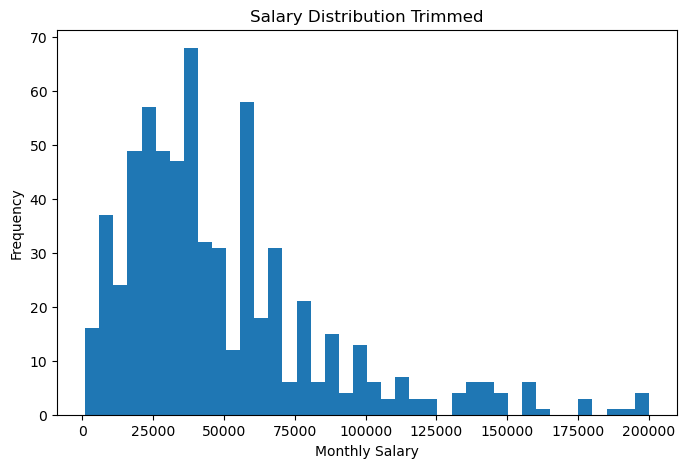

In [125]:
plt.figure(figsize=(8,5))
plt.hist(df_trimmed["salary_minimum"], bins=40)
plt.xlabel("Monthly Salary")
plt.ylabel("Frequency")
plt.title("Salary Distribution Trimmed")
plt.show()

In [113]:
df_trimmed[["salary_minimum","salary_maximum","salary_range"]].describe()

,salary_minimum,salary_maximum,salary_range
count,652,652,652
mean,"49,912","79,067","29,155"
std,"36,716","66,114","52,131"
min,"1,000","1,000",0
25%,"25,000","30,000",0
50%,"40,000","56,050",0
75%,"64,820","120,000","33,333"
max,"200,000","500,000","415,000"


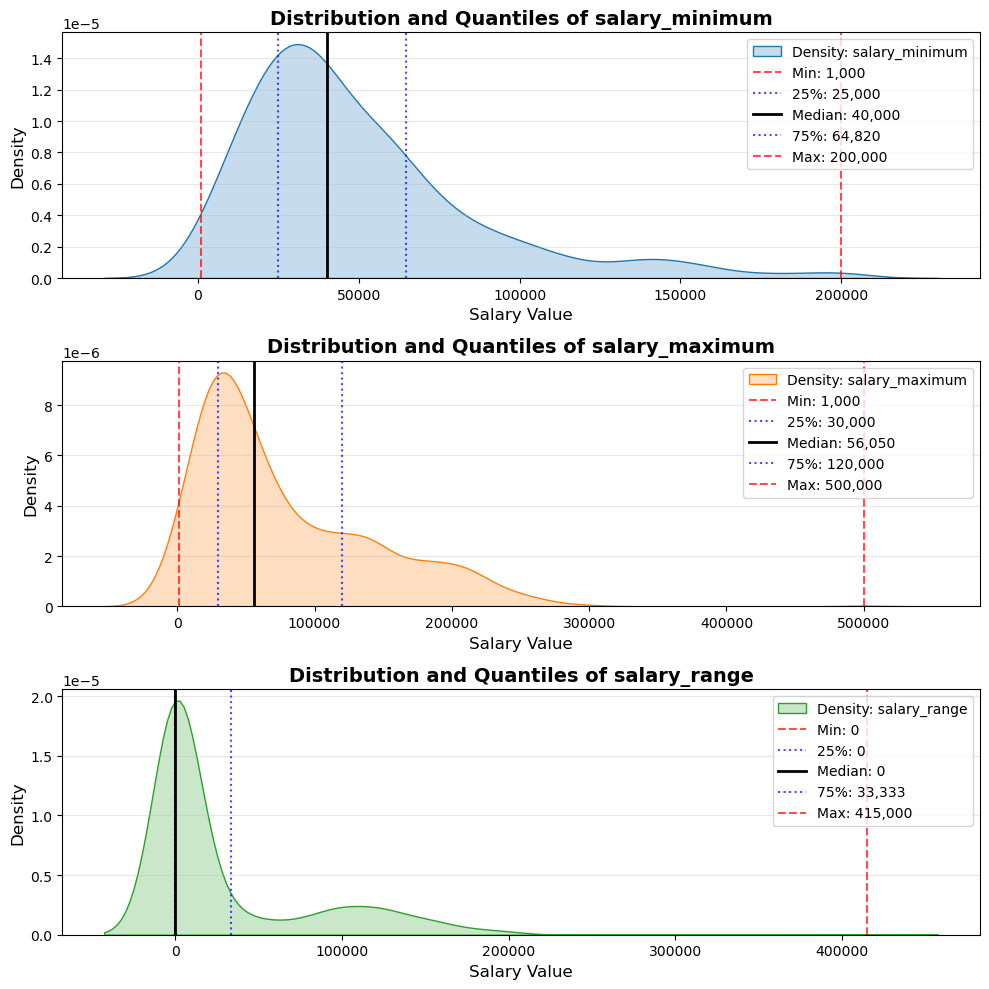

In [126]:
# 2. Define the columns we want to visualize
cols = ['salary_minimum', 'salary_maximum', 'salary_range']

# Plotting of the data
fig, axes = plt.subplots(3, 1, figsize=(10, 10))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Blue, Orange, Green

for i, col in enumerate(cols):
    sns.kdeplot(df_trimmed[col], ax=axes[i], fill=True, color=colors[i], label=f'Density: {col}')
    
    Min = df_trimmed[col].min()
    q1 = df_trimmed[col].quantile(0.25)
    q2 = df_trimmed[col].quantile(0.5)
    q3 = df_trimmed[col].quantile(0.75)
    Max = df_trimmed[col].max()
    metrics = {"Min":Min,"25%":q1,"50%":q2,"75%":q3,"Max":Max}

    axes[i].axvline(metrics['Min'], color='red', linestyle='--', alpha=0.7, label=f"Min: {metrics['Min']:,.0f}")
    axes[i].axvline(metrics['25%'], color='blue', linestyle=':', alpha=0.7, label=f"25%: {metrics['25%']:,.0f}")
    axes[i].axvline(metrics['50%'], color='black', linestyle='-', linewidth=2, label=f"Median: {metrics['50%']:,.0f}")
    axes[i].axvline(metrics['75%'], color='blue', linestyle=':', alpha=0.7, label=f"75%: {metrics['75%']:,.0f}")
    axes[i].axvline(metrics['Max'], color='red', linestyle='--', alpha=0.7, label=f"Max: {metrics['Max']:,.0f}")
    
    axes[i].set_title(f'Distribution and Quantiles of {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Salary Value', fontsize=12)
    axes[i].set_ylabel('Density', fontsize=12)
    axes[i].legend(loc='upper right', fontsize=10)
    axes[i].grid(axis='y', alpha=0.3)

# Adjust layout to prevent overlapping labels
plt.tight_layout()
plt.show()

## Bivarient Analysis 

#### 1. Numerical and Numerical column

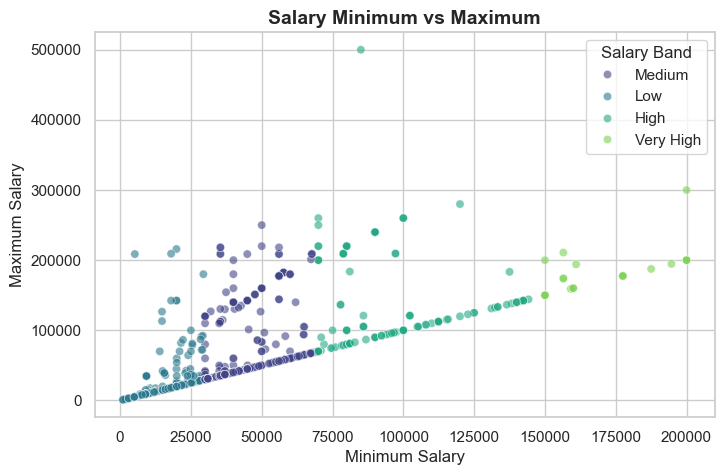

In [134]:
sns.set_theme(style="whitegrid")

# --- 1. Numerical to Numerical 
#   Salary_minimum and salary_maximum 
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_trimmed, x='salary_minimum', y='salary_maximum',hue='salary_band' ,alpha=0.6, palette='viridis')
plt.title('Salary Minimum vs Maximum', fontsize=14, fontweight='bold')
plt.xlabel('Minimum Salary')
plt.ylabel('Maximum Salary')
plt.legend(title='Salary Band')
plt.show()

#### 2. Numerical to Categorical Columns

##### Analysis Median Minimum and Maximum Salary based on Each category.
`Data is more skewed so we are using median as mesure.`

##### 1️⃣ Mean(Median) salary by qualification

In [150]:
df.groupby("qualification_level")[["salary_minimum", "salary_maximum"]].median().sort_values(by="salary_maximum", ascending=False)

,salary_minimum,salary_maximum
qualification_level,,
doctorate,"59,500","136,950"
postgraduate,"40,000","65,000"
other,"44,900","56,900"
undergraduate,"40,000","56,050"
school_level,"23,917","41,000"
diploma,"22,750","22,750"


##### 2️⃣ Mean(Median) salary by role_category

In [152]:
df.groupby("role_category")[["salary_minimum", "salary_maximum"]].median().sort_values(by="salary_maximum", ascending=False)

,salary_minimum,salary_maximum
role_category,,
Managerial,"60,000","120,940"
Academic,"36,400","102,350"
Officer,"60,000","97,108"
Medical,"60,000","95,000"
Engineer,"45,000","56,100"
Other,"40,000","55,300"
Assistant,"35,200","48,800"
Associate,"30,500","37,000"
Research,"35,400","37,000"


##### 3️⃣ Mean(Median) salary by sector

In [182]:
df.groupby("sector")[["salary_minimum", "salary_maximum"]].agg("median").sort_values(by="salary_maximum", ascending=False)

,salary_minimum,salary_maximum
sector,,
Energy,"52,500","105,000"
Healthcare,"56,100","105,000"
PSU,"50,000","92,300"
Judiciary,"44,900","80,000"
Government Admin,"45,415","76,450"
Banking,"48,480","65,000"
Government General,"40,000","65,000"
Education,"35,000","37,000"
Technical/Research,"36,000","37,000"


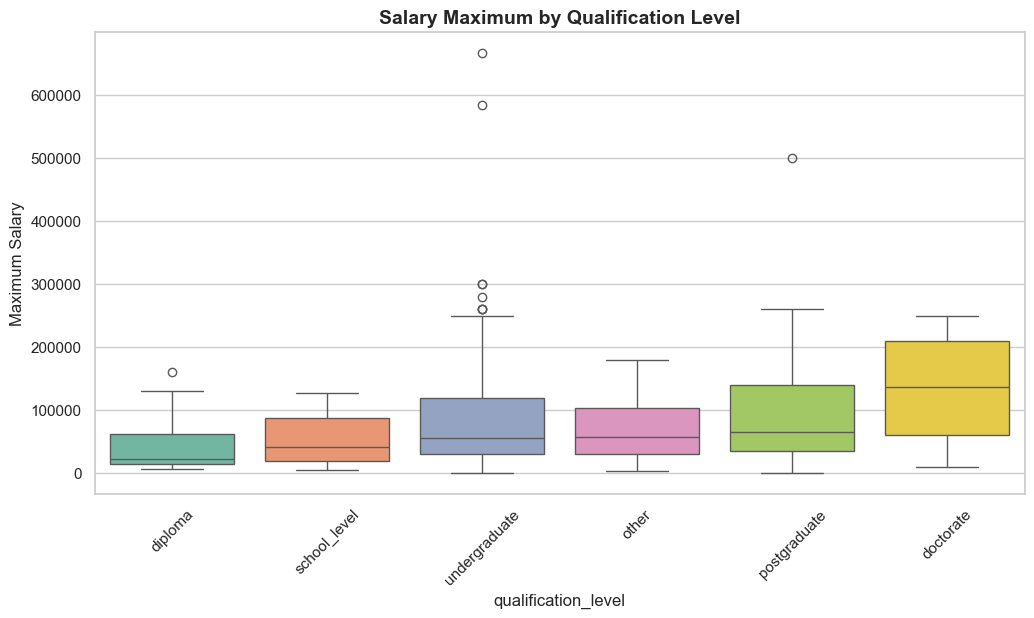

In [157]:
#  Salary_maximum and Qualification level
plt.figure(figsize=(12, 6))
order = df.groupby('qualification_level')['salary_maximum'].median().sort_values().index
sns.boxplot(data=df, x='qualification_level', y='salary_maximum', order=order, palette='Set2')
plt.title('Salary Maximum by Qualification Level', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Maximum Salary')
plt.show()

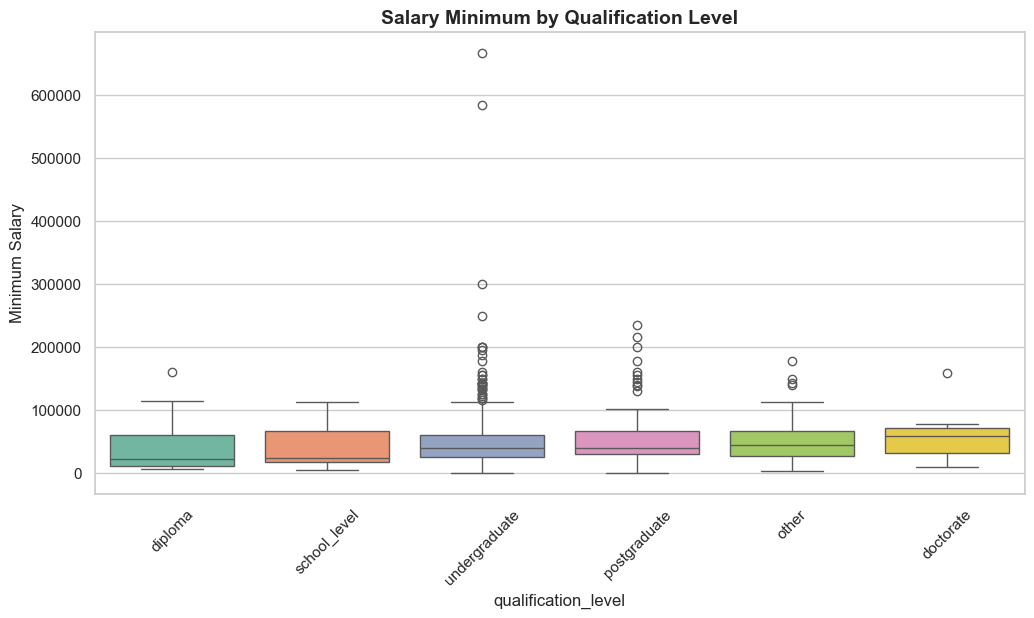

In [156]:
plt.figure(figsize=(12, 6))
order = df.groupby('qualification_level')['salary_minimum'].median().sort_values().index
sns.boxplot(data=df, x='qualification_level', y='salary_minimum', order=order, palette='Set2')
plt.title('Salary Minimum by Qualification Level', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Minimum Salary')
plt.show()

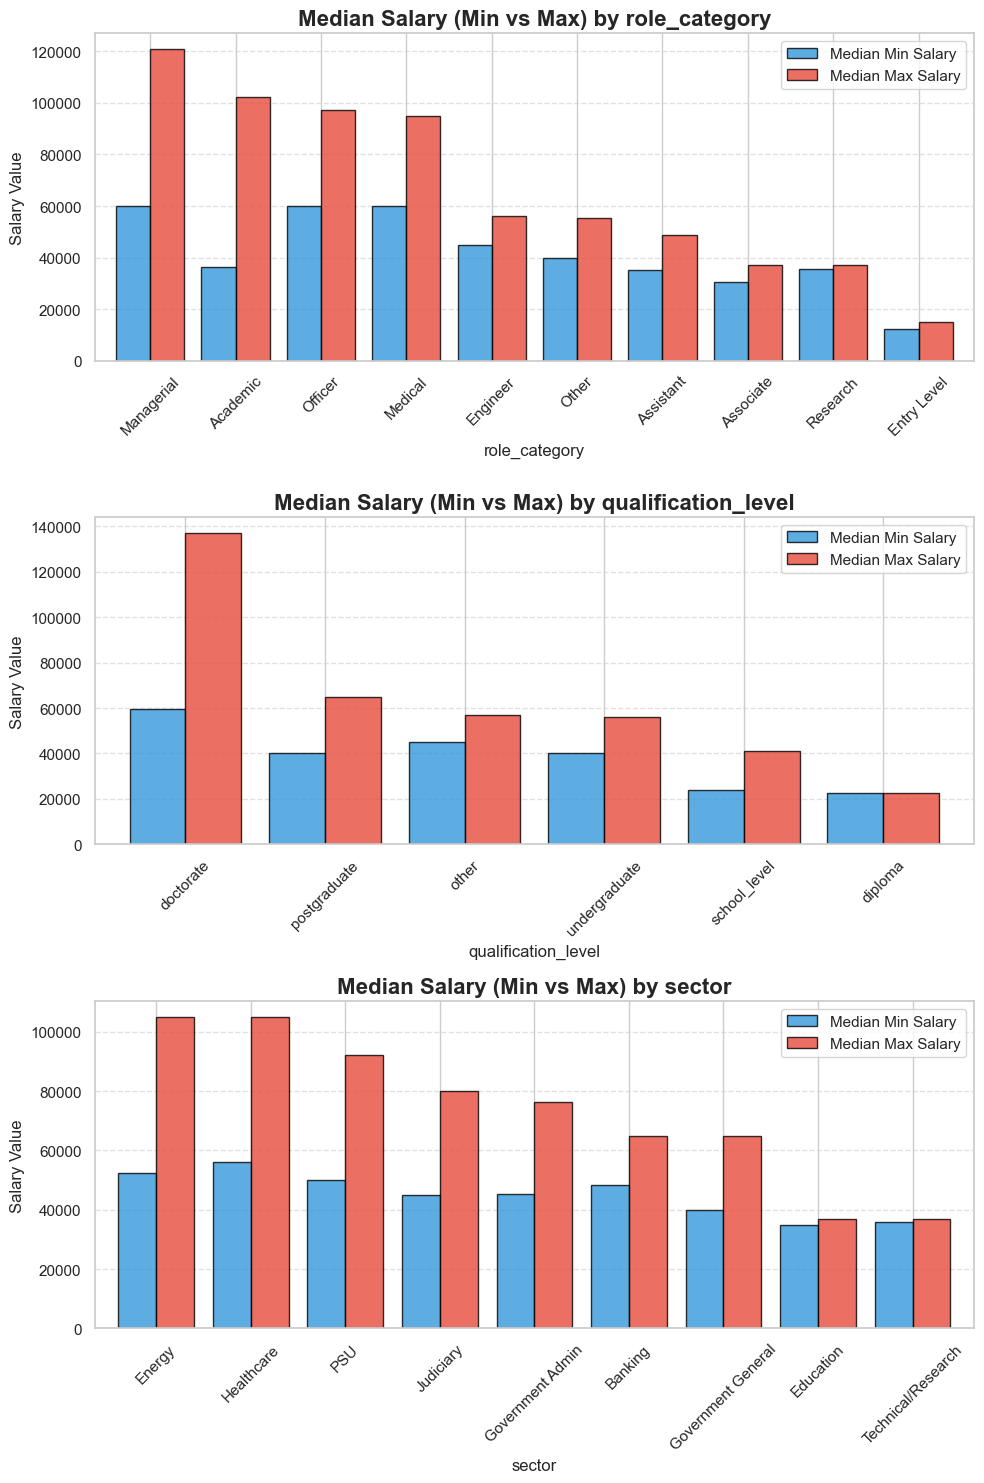

In [155]:
# Categorical columns to compare
cats = ['role_category', 'qualification_level', 'sector']

# Define a 3-row layout for comparison
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

for i, cat in enumerate(cats):
    grouped_df = df.groupby(cat)[['salary_minimum', 'salary_maximum']].median().sort_values(by='salary_maximum', ascending=False)
    grouped_df.plot(kind='bar', ax=axes[i], color=['#3498db', '#e74c3c'], width=0.8, edgecolor='black', alpha=0.8)
    
    axes[i].set_title(f'Median Salary (Min vs Max) by {cat}', fontsize=16, fontweight='bold')
    axes[i].set_ylabel('Salary Value', fontsize=12)
    axes[i].set_xlabel(cat, fontsize=12)
    axes[i].legend(["Median Min Salary", "Median Max Salary"], loc='upper right', frameon=True)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

# Final formatting
plt.tight_layout()
plt.show()

### Categorical vs Categoical

#### No of jobs between Qualification and Sector 

In [142]:
pd.crosstab(df["qualification_level"], df["sector"])

sector,Banking,Education,Energy,Government Admin,Government General,Healthcare,Judiciary,PSU,Technical/Research
qualification_level,,,,,,,,,
diploma,0,3,4,9,20,2,1,6,1
doctorate,0,12,0,1,3,0,0,0,0
other,8,27,1,5,30,4,6,6,2
postgraduate,18,69,2,16,59,4,3,6,4
school_level,1,6,1,9,24,0,2,3,0
undergraduate,79,121,23,91,238,6,22,44,17


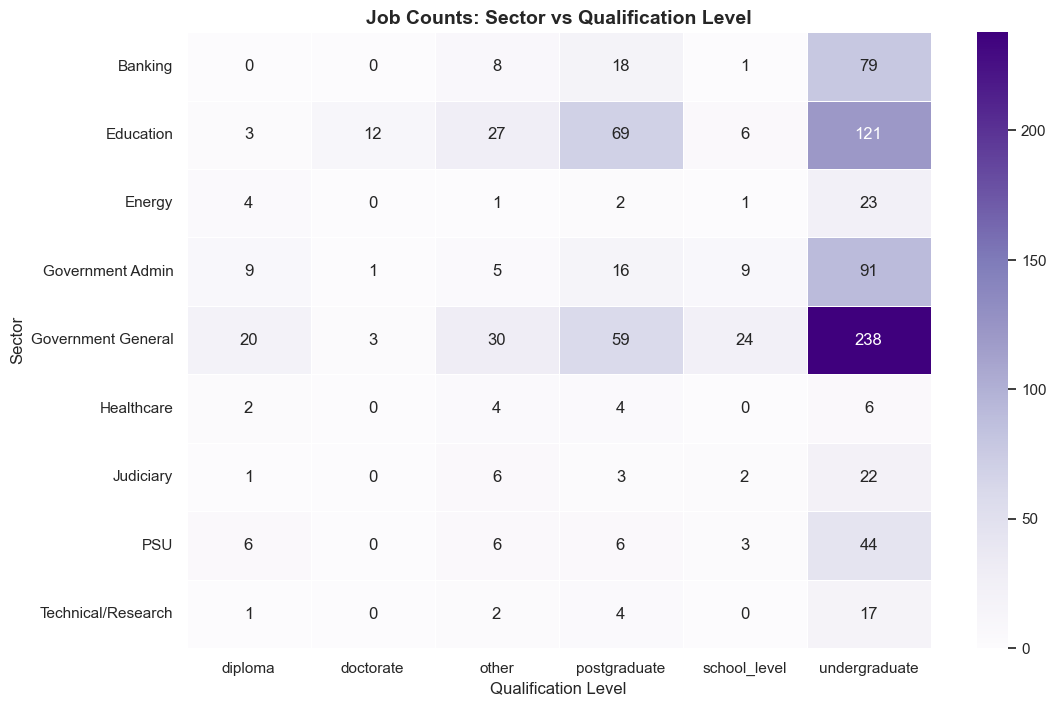

In [160]:
cat_ct = pd.crosstab(df['sector'], df['qualification_level'])

# --- Visualization A: Heatmap (Raw Counts) ---
plt.figure(figsize=(12, 8))
sns.heatmap(cat_ct, annot=True, fmt='d', cmap='Purples', linewidths=.5)
plt.title('Job Counts: Sector vs Qualification Level', fontsize=14, fontweight='bold')
plt.xlabel('Qualification Level', fontsize=12)
plt.ylabel('Sector', fontsize=12)
plt.show()

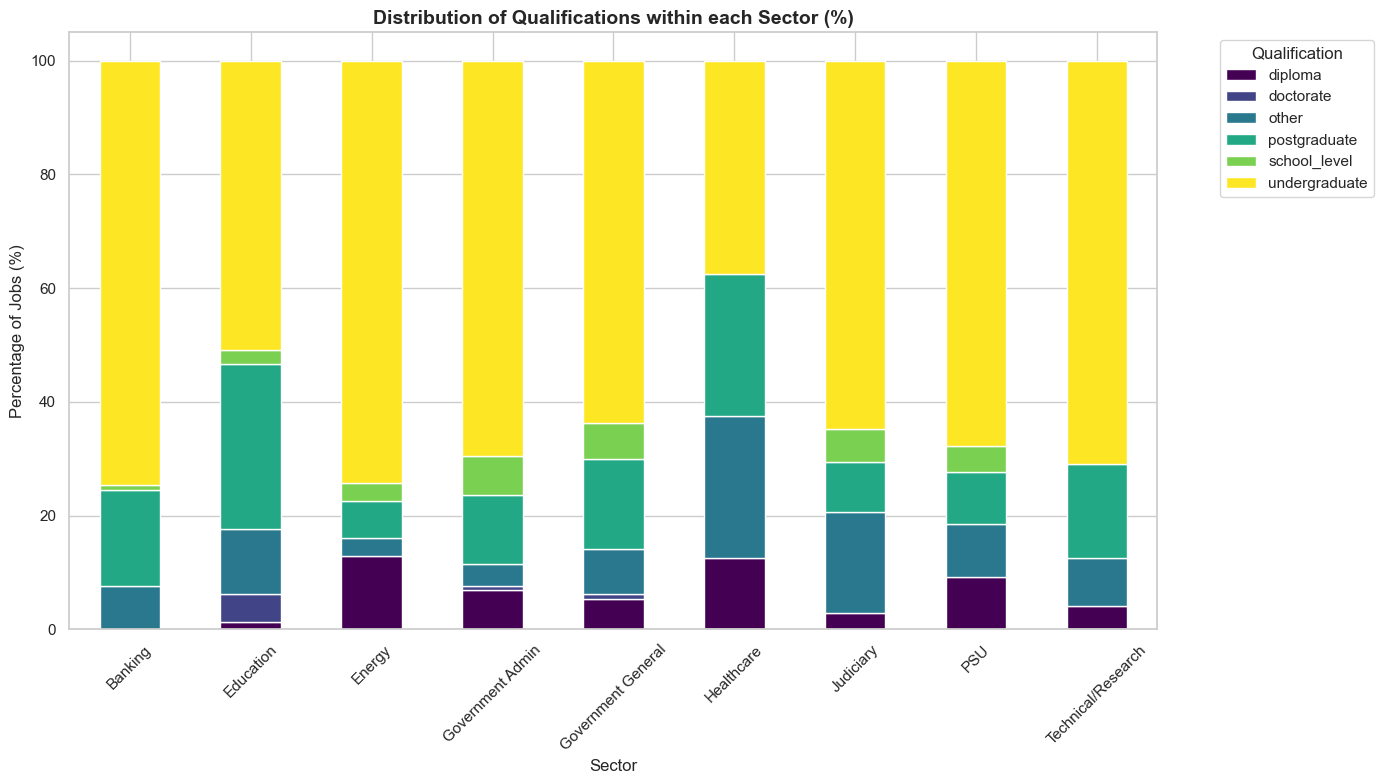

In [162]:
# Stacked Bar Chart (Proportions) ---
# Normalize the table to 100% so we can compare proportions across sectors
cat_ct_pct = pd.crosstab(df['sector'], df['qualification_level'], normalize='index') * 100

# Plotting
ax = cat_ct_pct.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='viridis', edgecolor='white')

# Formatting
plt.title('Distribution of Qualifications within each Sector (%)', fontsize=14, fontweight='bold')
plt.ylabel('Percentage of Jobs (%)', fontsize=12)
plt.xlabel('Sector', fontsize=12)
plt.legend(title='Qualification', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

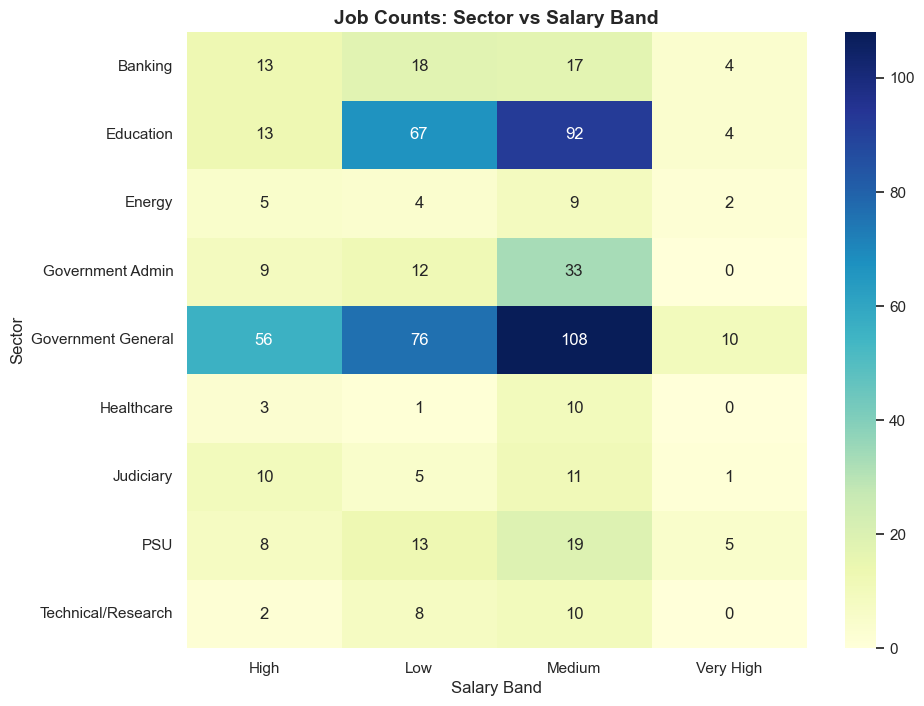

In [159]:
# --- 3. Categorical to Categorical (Heatmap) ---
# Create a cross-tabulation of two categorical variables
ct = pd.crosstab(df['sector'], df['salary_band'])
plt.figure(figsize=(10, 8))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Job Counts: Sector vs Salary Band', fontsize=14, fontweight='bold')
plt.xlabel('Salary Band')
plt.ylabel('Sector')
plt.show()

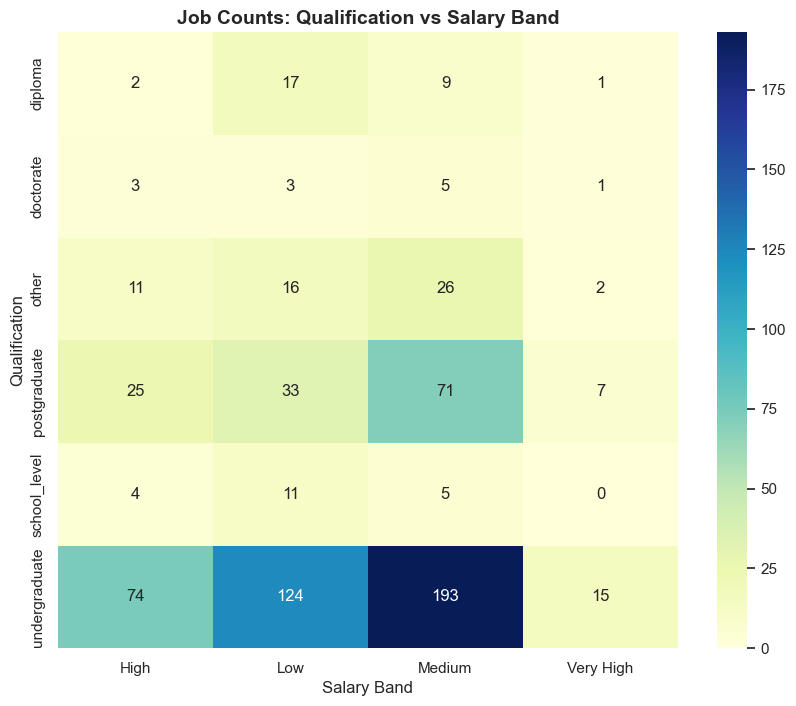

In [158]:
ct = pd.crosstab(df['qualification_level'], df['salary_band'])
plt.figure(figsize=(10, 8))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Job Counts: Qualification vs Salary Band', fontsize=14, fontweight='bold')
plt.xlabel('Salary Band')
plt.ylabel('Qualification')
plt.show()

## Multivarient Analysis

In [165]:
sns.set_theme(style="white")

#### 1. Min vs Max Salary by Role Category (Scatter Plot) ---

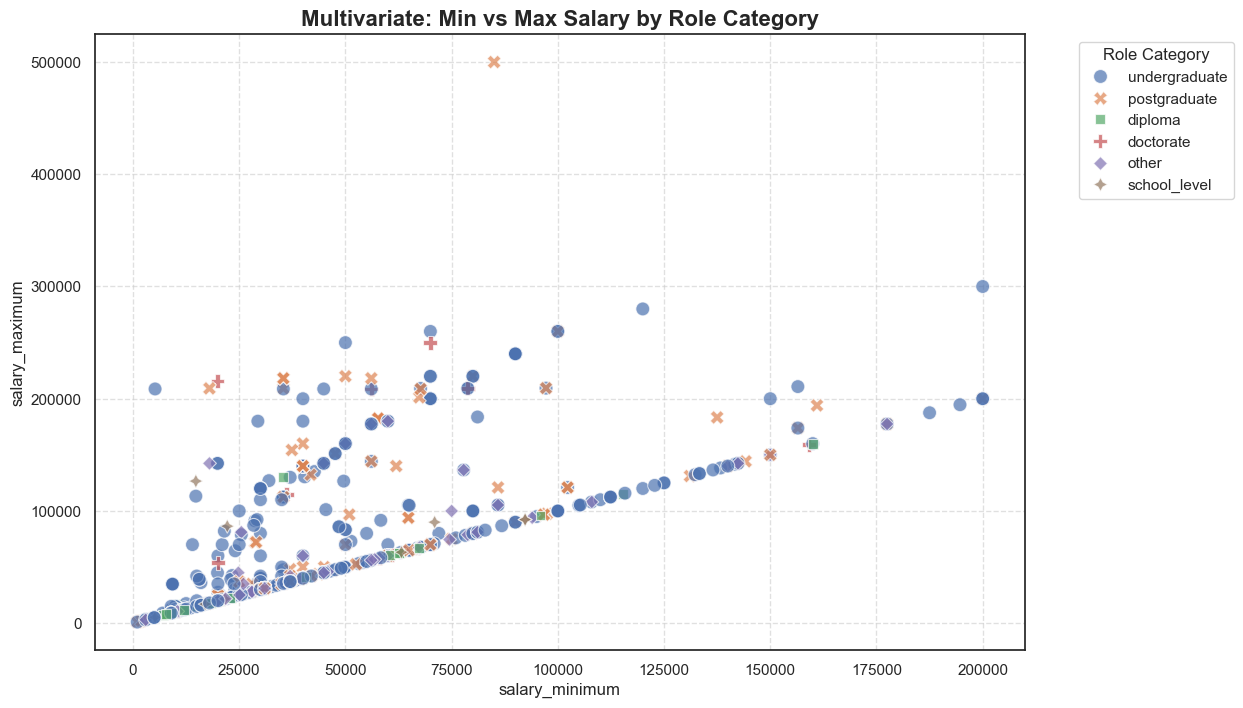

In [171]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_trimmed, x='salary_minimum', y='salary_maximum', 
                hue='qualification_level', style='qualification_level', s=100, alpha=0.7)
plt.title('Multivariate: Min vs Max Salary by Role Category', fontsize=16, fontweight='bold')
plt.legend(title='Role Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### 2. Average Salary Heatmap (Sector vs Qualification) ---

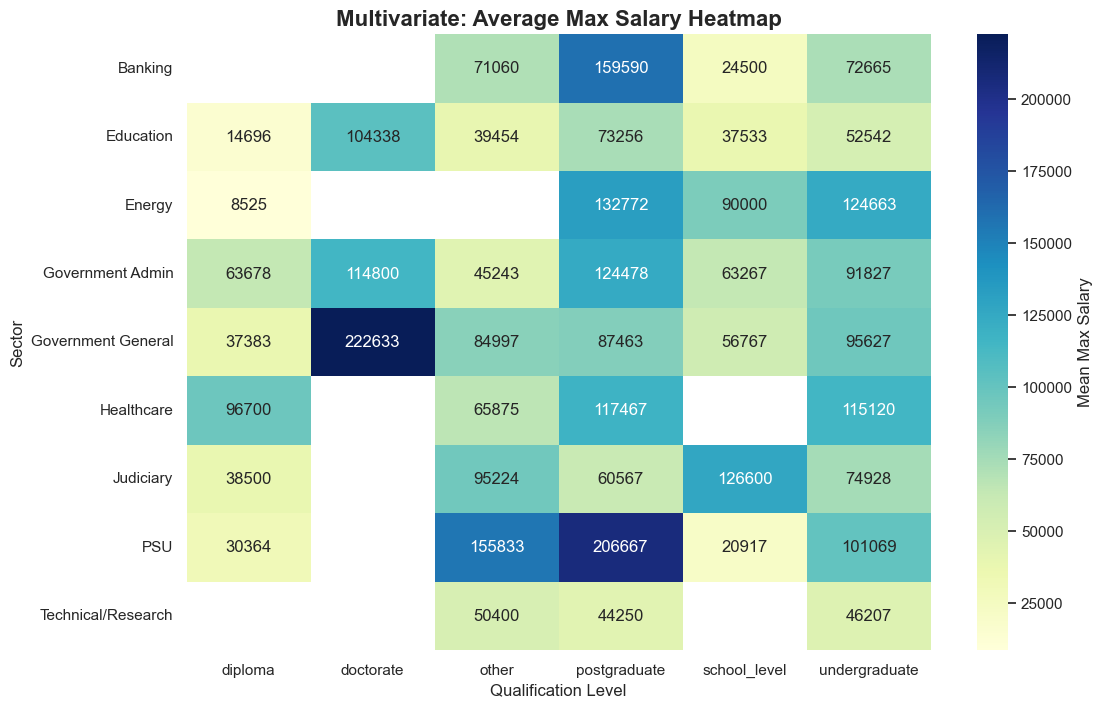

In [168]:
# We use a pivot table to get the mean salary for each combination
pivot_table = df.pivot_table(values='salary_maximum', index='sector', columns='qualification_level', aggfunc='mean')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap='YlGnBu', cbar_kws={'label': 'Mean Max Salary'})
plt.title('Multivariate: Average Max Salary Heatmap', fontsize=16, fontweight='bold')
plt.xlabel('Qualification Level')
plt.ylabel('Sector')
plt.show()

### 3. Compare Core vs Elite

In [163]:
df_elite = df_salary[df_salary["salary_minimum"] > upper_limit]

In [164]:
df_elite[["qualification_level", "sector", "role_category"]].value_counts()

qualification_level  sector              role_category
undergraduate        PSU                 Managerial       2
postgraduate         Banking             Other            1
                     PSU                 Managerial       1
undergraduate        Banking             Officer          1
                     Government General  Officer          1
Name: count, dtype: int64

###  Data which have most elites.

- Undergraduate → Managerial (PSU)
- Undergraduate → Officer (Banking / Govt General)
- Postgraduate → Managerial (PSU)

## insight
### High salaries are tied to:

- Administrative officers
- PSU managerial roles
- Banking officers